Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Schema validation passed successfully.
Standardized Column Names:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']
Shape: (7043, 21)

Data Types:
 customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn             

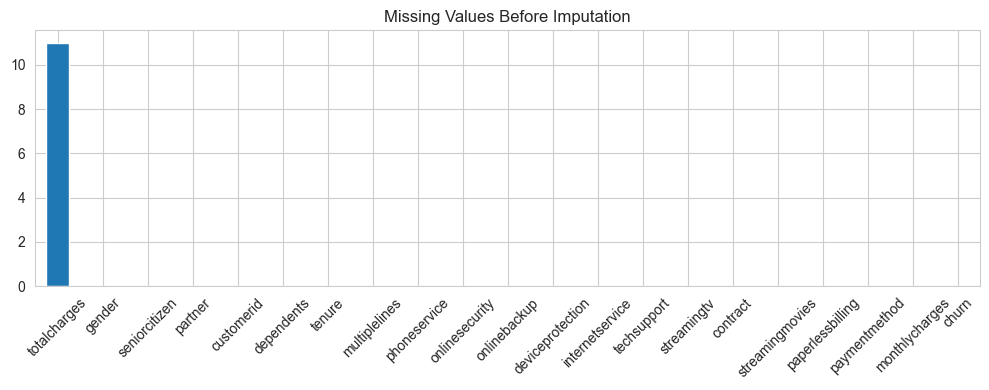

Remaining null values after imputation: 0


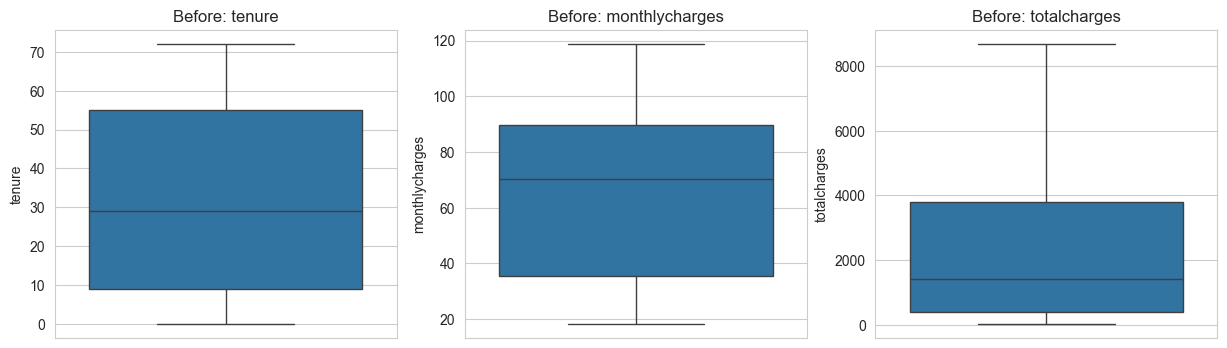

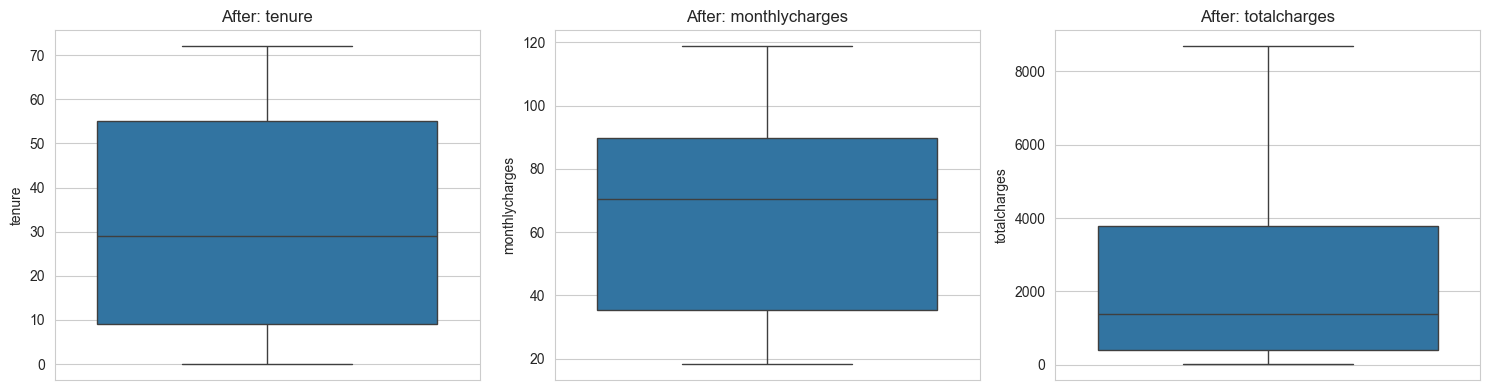

Cleaned dataset saved successfully to data/processed/telco_cleaned.csv


In [ ]:
# ============================================================
# 01_EDA.ipynb — Phase 2: Data Understanding + Cleaning
# ============================================================

# ============================================================
# Section 1 — Objective
# ============================================================
# Phase 2: Data Understanding + Cleaning
#
# Objective:
# - Load raw telecom churn dataset
# - Validate schema and structure
# - Identify data quality issues
# - Fix datatype inconsistencies
# - Handle missing values
# - Treat outliers
# - Save cleaned dataset for downstream EDA and modeling


# ============================================================
# Section 2 — Imports
# ============================================================
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../")

from src.data_loader import (
    load_data,
    validate_schema,
    standardize_column_names,
    inspect_data,
    fix_totalcharges,
    handle_missing_values,
    treat_outliers_iqr,
    save_clean_data,
)

from src.utils import save_figure

sns.set_style("whitegrid")


# ============================================================
# Section 3 — Load Dataset
# ============================================================
df = load_data("../data/raw/Telco-Customer-Churn.csv")

print("Shape:", df.shape)
display(df.head())


# ============================================================
# Section 4 — Validate Schema
# ============================================================
validate_schema(df)
print("Schema validation passed successfully.")


# ============================================================
# Section 5 — Standardize Column Names
# ============================================================
df = standardize_column_names(df)

print("Standardized Column Names:")
print(df.columns.tolist())


# ============================================================
# Section 6 — Inspect Data Quality
# ============================================================
summary = inspect_data(df)

print("Shape:", summary["shape"])
print("\nData Types:\n", summary["dtypes"])
print("\nNull Counts:\n", summary["null_counts"])
print("\nDuplicate Rows:", summary["duplicate_rows"])


# ============================================================
# Section 7 — Fix TotalCharges
# ============================================================
print("Before fixing totalcharges dtype:", df["totalcharges"].dtype)

df = fix_totalcharges(df)

print("After fixing totalcharges dtype:", df["totalcharges"].dtype)
print("Nulls introduced in totalcharges after coercion:", df["totalcharges"].isnull().sum())


# ============================================================
# Section 8 — Missing Values
# ============================================================
plt.figure(figsize=(10, 4))
df.isnull().sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Values Before Imputation")
plt.xticks(rotation=45)
save_figure("../reports/figures/missing_values.png")
plt.show()

df = handle_missing_values(df)

print("Remaining null values after imputation:", df.isnull().sum().sum())


# ============================================================
# Section 9 — Outlier Treatment
# ============================================================
numeric_cols = ["tenure", "monthlycharges", "totalcharges"]

# Before outlier treatment
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Before: {col}")
plt.show()

# Apply IQR capping
df = treat_outliers_iqr(df, numeric_cols)

# After outlier treatment
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"After: {col}")

save_figure("../reports/figures/outliers_before_after.png")
plt.show()


# ============================================================
# Section 10 — Save Cleaned Dataset
# ============================================================
save_clean_data(df, "../data/processed/telco_cleaned.csv")
print("Cleaned dataset saved successfully to data/processed/telco_cleaned.csv")


# ============================================================
# Section 11 — Summary
# ============================================================
# Summary:
# - Raw telecom dataset loaded successfully
# - Schema validated against expected structure
# - Column names standardized
# - TotalCharges converted to numeric and corrected
# - Missing values handled using:
#     numeric -> median
#     categorical -> mode
# - Outliers treated using IQR capping
# - Clean dataset saved for EDA and downstream modeling



Cleaned dataset shape: (7043, 21)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


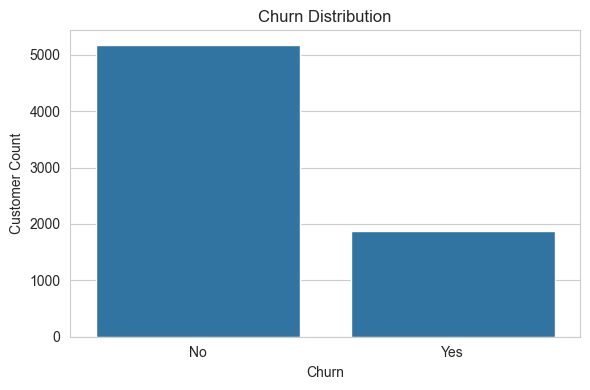

Churn Class Distribution (%):
churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


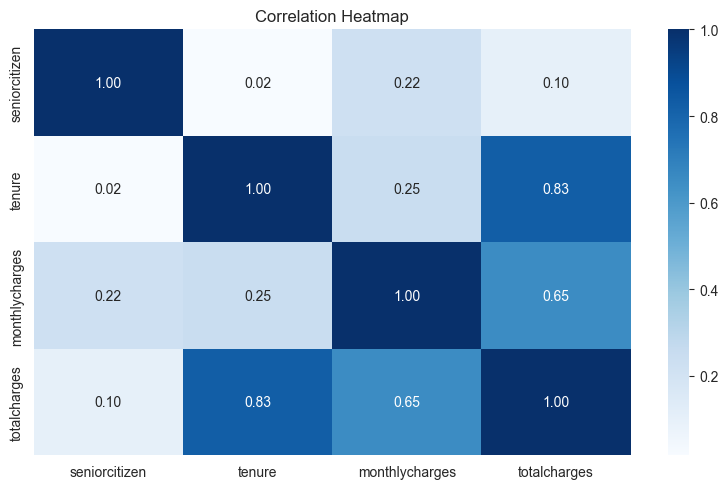

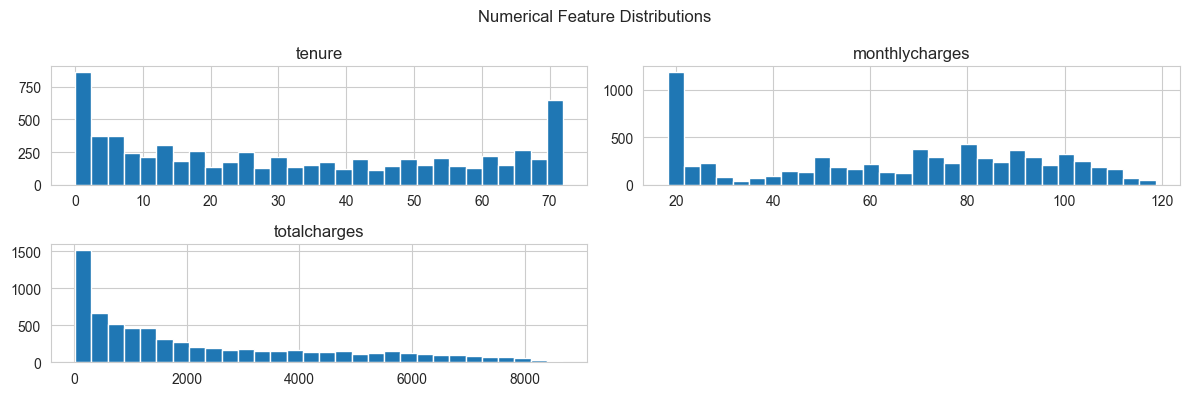

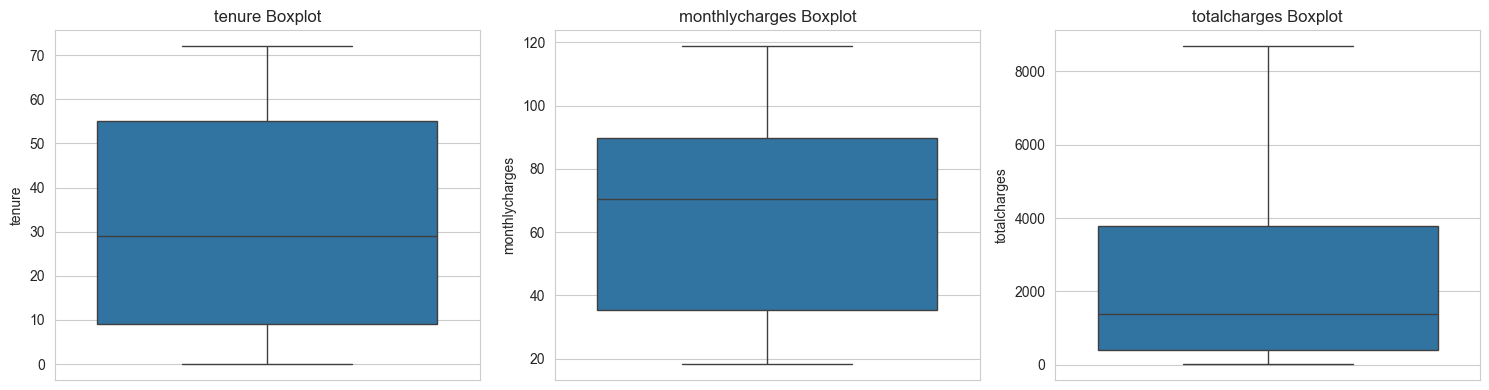

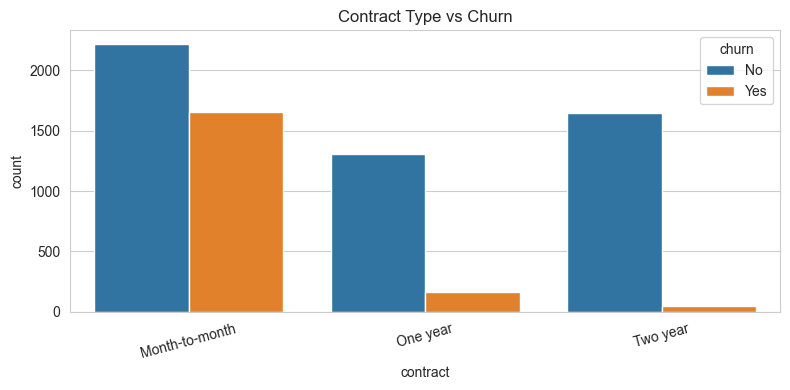

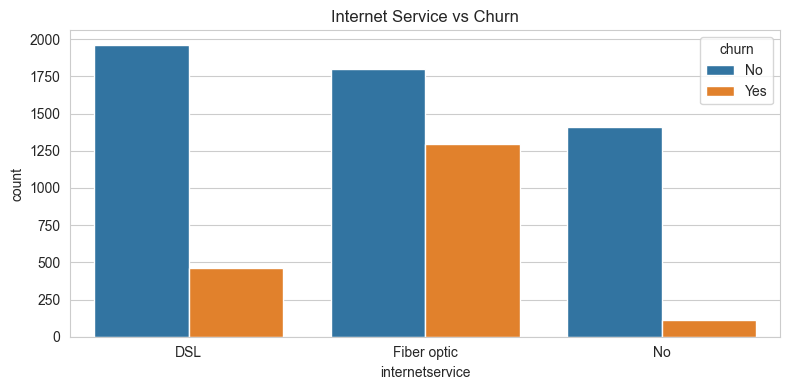

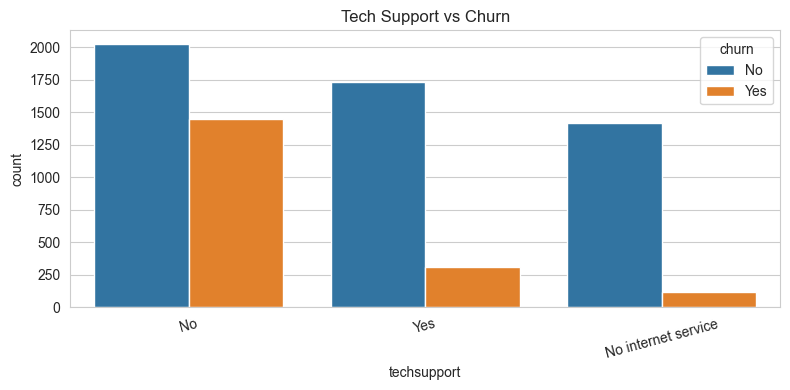

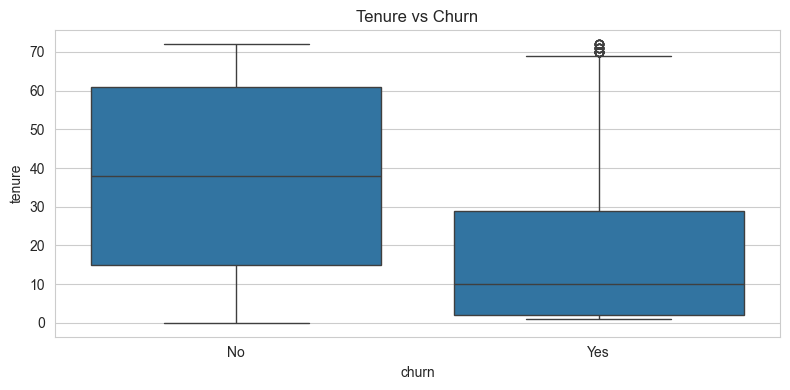

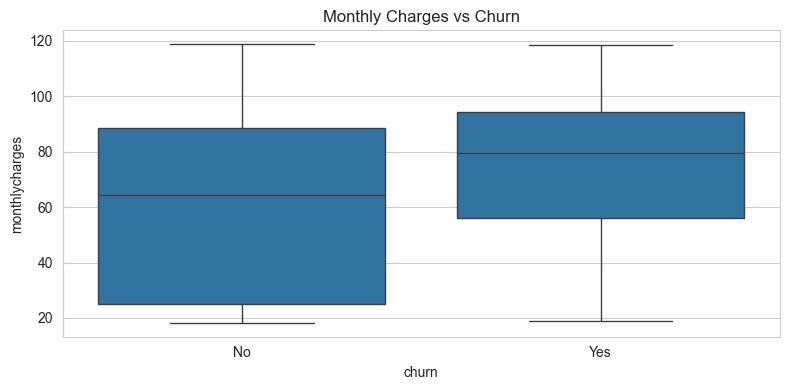

In [2]:
# ============================================================
# Section 12 — Load Cleaned Dataset for EDA
# ============================================================
df = pd.read_csv("../data/processed/telco_cleaned.csv")

print("Cleaned dataset shape:", df.shape)
display(df.head())


# ============================================================
# Section 13 — Class Imbalance Analysis
# ============================================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
save_figure("../reports/figures/churn_distribution.png")
plt.show()

print("Churn Class Distribution (%):")
print(df["churn"].value_counts(normalize=True) * 100)

# Insight:
# - The dataset is moderately imbalanced.
# - Most customers are retained.
# - Churn prediction requires imbalance-aware modeling.


# ============================================================
# Section 14 — Correlation Heatmap
# ============================================================
numeric_df = df[["seniorcitizen", "tenure", "monthlycharges", "totalcharges"]]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
save_figure("../reports/figures/correlation_heatmap.png")
plt.show()

# Insight:
# - tenure and totalcharges are strongly positively correlated
# - monthlycharges has weaker correlation with tenure
# - no severe multicollinearity among predictors


# ============================================================
# Section 15A — Numerical Feature Distributions
# ============================================================
df[["tenure", "monthlycharges", "totalcharges"]].hist(figsize=(12, 4), bins=30)
plt.suptitle("Numerical Feature Distributions")
save_figure("../reports/figures/numerical_distributions.png")
plt.show()

# Insight:
# - tenure is right-skewed
# - monthly charges show broad spread
# - total charges remain positively skewed even after capping


# ============================================================
# Section 15B — Numerical Feature Boxplots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["tenure", "monthlycharges", "totalcharges"]):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot")

save_figure("../reports/figures/numerical_boxplots.png")
plt.show()


# ============================================================
# Section 16A — Contract vs Churn
# ============================================================
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="contract", hue="churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
save_figure("../reports/figures/contract_vs_churn.png")
plt.show()


# ============================================================
# Section 16B — Internet Service vs Churn
# ============================================================
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="internetservice", hue="churn")
plt.title("Internet Service vs Churn")
save_figure("../reports/figures/internetservice_vs_churn.png")
plt.show()


# ============================================================
# Section 16C — Tech Support vs Churn
# ============================================================
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="techsupport", hue="churn")
plt.title("Tech Support vs Churn")
plt.xticks(rotation=15)
save_figure("../reports/figures/techsupport_vs_churn.png")
plt.show()


# ============================================================
# Section 16D — Tenure vs Churn
# ============================================================
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure vs Churn")
save_figure("../reports/figures/tenure_vs_churn.png")
plt.show()


# ============================================================
# Section 16E — Monthly Charges vs Churn
# ============================================================
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="churn", y="monthlycharges")
plt.title("Monthly Charges vs Churn")
save_figure("../reports/figures/monthlycharges_vs_churn.png")
plt.show()


# ============================================================
# Section 17 — Business Insights
# ============================================================
# Business Insights:
#
# 1. Contract type is the strongest churn signal
#    Customers on month-to-month contracts churn significantly more than
#    customers on one-year and two-year contracts, suggesting long-term
#    contracts improve retention.
#
# 2. Customers without tech support churn more
#    Customers who do not subscribe to Tech Support show much higher churn,
#    indicating support services improve customer stickiness.
#
# 3. High monthly charges are associated with churn
#    Customers with higher monthly charges churn more frequently,
#    suggesting pricing sensitivity is a major churn driver.
#
# 4. Newer customers are more likely to churn
#    Customers with lower tenure churn more often, indicating churn risk
#    is highest early in the customer lifecycle.
#
# 5. Fiber optic users show elevated churn
#    Fiber optic customers churn more than DSL users, potentially due to
#    pricing, service expectations, or dissatisfaction.